<a href="https://colab.research.google.com/github/Stefano-Florprado/python-learning-notes/blob/main/lezione-3/lezione-3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lezione 3: Object-Oriented Programming (OOP)

### Contatti
[matteo.caldana@polimi.it](mailto:matteo.caldana@polimi.it).

## Introduzione

La programmazione orientata agli oggetti (OOP) è un paradigma di programmazione che rappresenta entità del mondo reale utilizzando classi e oggetti. Le classi fungono da modelli, mentre gli oggetti sono istanze di queste classi.

In breve:
- **classe** l'idea (es. `list`)
- **oggetto/istanza** la concretizzazione dell'idea (es. [1, 2, 3])

## In Python tutto è un oggetto

Forse, il modo migliore di capire le classi, è scoprire che tutto quello che abbiamo utilizzato fino ad ora sono classi/oggetti.

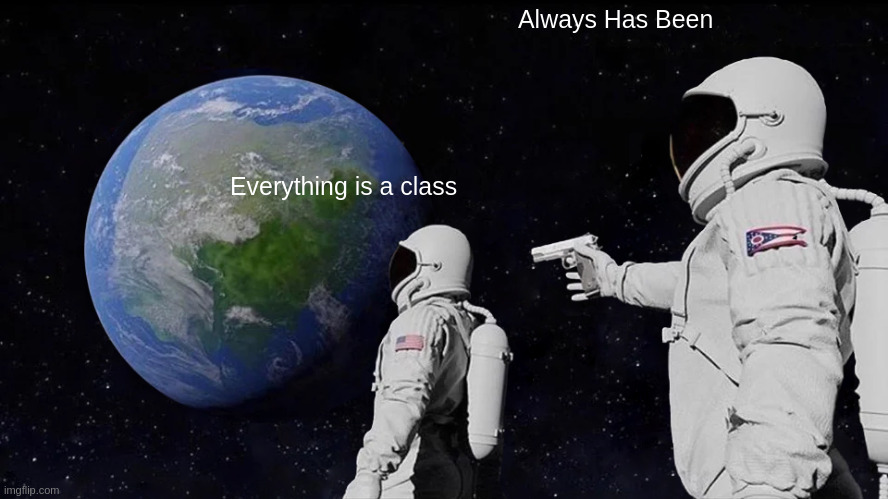

In [1]:
example_number = 1234
print(type(example_number))

example_string = 'hello there'
print(type(example_string))

example_list = [1, 2, 3, 4]
print(type(example_list))

# anche le funzioni sono classi!!!
def example_function():
    return
print(type(example_function))

<class 'int'>
<class 'str'>
<class 'list'>
<class 'function'>


Tutte le variabili che abbiamo utilizzato sono un **oggetto**, con un tipo e una serie di “istruzioni” per interagire con esso.
Un oggetto è, in breve, un'**istanza** di una particolare classe:

“hello there” è un'istanza di stringa


Gli oggetti sono astrazioni di dati che forniscono:
- una rappresentazione interna attraverso attributi di dati
- un'interfaccia per interagire con gli oggetti (funzioni?)

## Perchè creare una classe?

Non dobbiamo sentirci obbligati ad utilizzare classi, a volte una semplice funzione funziona benissimo (pun intended). Tuttavia, a volte, per avere un codice più ordinato fa comodo avere in un posto solo tutto quello che ci serve.

Supponiamo di volere creare una classe Utente per gestire vari utenti su una piattaforma.

In [6]:
class UserClass:
    # variabili legate alla classe, tutti gli user l'hanno uguale
    platform = "Nexus"

    # metodo, notate che il primo argomento deve essere sempre `self`.
    # `self` è una keyword!
    # Un metodo è una funzione qualunque, in cui il primo argomento è
    # l'istanza, quindi se vogliamo interagirci deve essere tra gli argomenti
    def send_email(self, text):
        return f"Sending to {self.email}: '{text}'"

    # metodo speciale per creare una nuova instanze
    def __init__(self, username, email):
        # variabili legate all'oggetto
        self.username = username
        self.email = email


# creiamo l'istanza
user = UserClass("Stefano", "stefano@dev.com")
# chiamiamo un metodo
user.send_email("Ciao, come stai?")
#UserClass.send_email(user, "Nuovo messaggio") alternativca più esplicita

"Sending to stefano@dev.com: 'Nuovo messaggio'"

#### Attenzione
Python è molto flessibile, ci lascia accedere in lettura e scrittura agli attributi, tuttavia non andrebbero toccati

In [4]:
print(user.username)
# MALE: non si dovrebbe toccare!
user.username = "Bob"
print(user.username)

# MALE^2: stiamo creando un nuovo attributo della classe
user.address = "Should not do this street, London"

Stefano
Bob


### Metodi speciali: `classmethod` e `staticmethod`

Vediamo ora due tipi speciali di metodo: a volte sono necessari metodi che non tengono conto dei dati specifici di un utente, ma che appartengono comunque alla famiglia `User`.

* Metodi di classe (`@classmethod`): spesso utilizzati come “factory methods” per creare oggetti in modi diversi. Sono metodi non legati all'istanza ma alla classe.

* Metodi statici (`@staticmethod`): semplici funzioni di utilità che risiedono all'interno della classe per motivi di organizzazione, ma che non influiscono sullo stato della classe o dell'istanza.

In [9]:
class User:
    def __init__(self, username, email):
        self.username = username
        self.email = email

    # stiamo passando la classe come primo argomento (invece di self)
    # si, anche la classe `User` è l'istanza di una classe
    @classmethod
    def from_string(cls, user_str):
        # Creates a user from a "Name-Email" string
        username, email = user_str.split("-")
        return cls(username, email) #è una classe come User

    @staticmethod
    def is_secure(password):
        # A utility to check password length
        return len(password) >= 8


user = User.from_string("Claude-claude@dev.com")

print("Is password secure?", User.is_secure("AAAAaaaa"))
# check: anche una classe è una classe
print(type(User)) #la classe è un oggetto che si differisce a tutti gli altri oggetti, infatti è un tipo type

Is password secure? True
<class 'type'>


## Inheritance: minimizzare la duplicazione del codice

Supponiamo ora che vogliamo creare un'altra classe per un utente che ha più poteri (cioè, altri metodi che permettono di fare cose che un utente normale non può fare). Fare copia-incolla del codice di User è un'idea terribile: nel caso sforturato dovessimo fare una modifica a User, dovremmo farla in due punti.

L'inheritance ci permette di ereditare tutta la struttura di una classe (detta "base" o "parent") in una nuova classe (detta "derived" o "child").

In [10]:
class Admin(User):
    def __init__(self, username, email):
        # Use super() to call the parent's __init__
        super().__init__(username, email) #prima bisgna costruire tutti i genitori poi fare tutte le altre operazioni che si vuole

    def delete_user(self, user):
        return f"Admin {self.username} deleted {user.username}"

admin = Admin("David", "david@dev.com")
admin.delete_user(user)

'Admin David deleted Claude'

## Aggiungiamo struttura e regole: le classi astratte
A volte è utile avere una classe “base” che non è destinata ad essere utilizzata da sola, ma che funge da modello per altre classi. A questo scopo utilizziamo il modulo `abc`.

In [11]:
from abc import ABC, abstractmethod #abstract basic class

class BaseUser(ABC):
    # tutte le classi derivate di `BaseUser` devono
    # definire un'implementazione di questo metodo
    @abstractmethod
    def get_permissions(self):
        pass

class StandardUser(BaseUser):
    def get_permissions(self):
        return ["read", "post"]

# Nota: non è possibile creare un'istanza di BaseUser.
# Se si tenta di farlo, Python genererà un errore.
# Si tratta di un contratto che stabilisce che “ogni utente DEVE implementare get_permissions”.
# base_user = BaseUser()

standard_user = StandardUser()

## Rules are made to be broken: Duck typing
Queste strutture extra in Python non servono a quasi a nulla se non per noi ad avere un codice più pulito. Infatti, Python è talmente flessibile da seguire il principio:
*"If it walks like a duck and quacks like a duck, it’s a duck."*

In [12]:
# Sarebbe auspicabile in questo caso avere una classe base con un metodo
# login astratto, che definisce in maniera chiara un contratto.
# Tuttavia, possiamo prendere classi completamente scollegate ed usare i
# loro metodi come se fossero inparentate

class RawAdmin():
    def login(self):
        print("Admin logged-in")

class RawUser():
    def login(self):
        print("User logged-in")

users = [RawAdmin(), RawUser()]
for user in users:
    # il metodo login è il quack, lo user è la duck
    user.login()

Admin logged-in
User logged-in


### Opinioni forti
Per quanto possibile evitate di usare il duck typing, preferite invece un codice più strutturato. Anche se non necessario, avere delle classi di base astratte vi aiuta a mantenere un codice pulito!

## Interazioni tra classi: aggregation, composition and association

Quando progettiamo un sistema, dobbiamo decidere quanto “controllo” un oggetto ha su un altro.

La relazione più forte, e che non va abusata, è "is-a", e corrisponde all'inheritance. Es. un Admin è uno User.

Una relazione leggermete più debole è “has-a”, ma in questo caso esiste su uno spettro di dipendenza che ora dettagliamo.

#### Associazione

L'associazione è la relazione più basilare. Due oggetti sono consapevoli l'uno dell'altro, ma le loro vite sono completamente indipendenti.

Esempio: un utente si connette a un server. L'utente esiste senza il server e il server esiste senza quell'utente specifico.

In [13]:
class Server:
    def __init__(self, ip):
        self.ip = ip

class User:
    def __init__(self, username):
        self.username = username

    def connect_to(self, server):
        # stiamo sfruttando implicitamente il fatto che sappiamo
        # che un oggetto Sever ha l'attributo `ip`
        print(f"{self.username} is accessing {server.ip}")

# Independent lifetimes
web_server = Server("192.168.1.1")
me = User("Dev_Dan")
me.connect_to(web_server)

Dev_Dan is accessing 192.168.1.1


#### Aggregazione (relazione "contiene")

L'aggregazione è una forma specializzata di associazione in cui un oggetto “contiene” altri oggetti, ma gli oggetti contenuti possono esistere autonomamente. Si tratta di una proprietà “debole”.

Esempio: un team ha più oggetti utente. Se il team viene eliminato, gli oggetti utente continuano a esistere nel database.

In [14]:
class Team: #es. gruppo telegram con una lista di utenti
    def __init__(self, team_name, members=None):
        self.team_name = team_name
        # The User objects exist outside this class
        self.members = members if members else []

    def add_member(self, user):
        self.members.append(user)

# If we delete 'alpha_team', the 'user_1' object remains intact.
user_1 = User("Alice")
alpha_team = Team("Alpha Squad", [user_1])

#### Composizione (relazione “essere una parte di”)

La composizione è la relazione più forte (comunque più debole dell'inheritance). In questo caso, l'oggetto “figlio” è parte del “genitore” e non può esistere senza di esso. Se il genitore viene distrutto, anche il figlio muore. Un buon programmatore dovrebbe sempre chiedersi quale relazione sia più adatta tra inheritance e composizione, perchè la risposta non è sempre chiara.

Esempio: un utente ha un profilo. Non manterresti un profilo se l'account utente venisse eliminato. Tuttavia l'utente è molto di più del suo profilo (contiente informazioni sulle sue preferenze, informaioni private sui log-in, ecc.). Inoltre, anche un Team potrebbe avere un profilo, quindi ha senso che sia una classe separata.

In [15]:
class Profile:
    def __init__(self, bio):
        self.bio = bio

class User:
    def __init__(self, username, bio):
        self.username = username
        # The Profile is CREATED inside the User.
        # It is part of the User's lifecycle.
        self.profile = Profile(bio)

# Deleting 'my_user' will also wipe the associated Profile object.
my_user = User("Bob", "Just a guy who loves Python.")

## Andandiamo in profondità: dunder methods (aka magic methods)

I metodi Dunder (Double Underscore) sono metodi speciali che Python chiama dietro le quinte. Consentono alle classi personalizzate di rispondere a operazioni integrate come print(), len() o persino addizione e sottrazione.

In [18]:
import math

class Point:
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def __str__(self):
        # Returns a readable coordinate format
        return f"({self.x}, {self.y})"

    def __len__(self):
        return 2

    def __add__(self, other):
        """Allows p1 + p2 syntax."""
        if not isinstance(other, Point):
            return NotImplemented
        return Point(self.x + other.x, self.y + other.y)

    def __eq__(self, other):
        """Returns True if x and y coordinates match."""
        if not isinstance(other, Point):
            return False
        return self.x == other.x and self.y == other.y

    def __abs__(self):
        """Calculates the distance from the origin (0, 0)."""
        # Formula: sqrt(x^2 + y^2)
        return math.sqrt(self.x**2 + self.y**2)


p1 = Point(3, 4)
p2 = Point(1, 2)

print(p1)
print(len(p1))

# Using __add__
p3 = p1 + p2
print(p3)  # Output: (4, 6)

# Using __abs__
print(abs(p1)) # Output: 5.0

# Using __eq__
print(p1 == p2)
print(p1 + p2 == Point(4, 6))

(3, 4)
2
(4, 6)
5.0
False
True


In [28]:
dummy_dati = """date, temp, wind
2026-03-10, 10.1, 5.2
2026-03-11, 15.1, 6.2
2026-03-12, 19.1, 0.2
"""

with open ("dummy.csv", "w") as fp:
  fp.write(dummy_dati)

class MyCSV:
  def __init__(self, list_of_data):
    self.data = {}
    if len(list_of_data) == 0:
      return
    for field in list_of_data[0]:
      self.data[field]=[]
    for row in list_of_data:
      for field in row:
        if field in self.data:
          self.data[field].append(row[field])
        else:
          raise Exception("Field formatting is not consistent")

    @classmethod
    def read_csv(cls, filename):
      with open(filename, "r") as fp:
        content=fp.read()
      content=content.split("\n")
      print(content)
      field=content[0].split(",")
      print(field)
      data=[]
      for row in range(1,len(content)):
        row=content[1].split(",")
        if len(row) == len(field):
          row_dict={}
          for j in range(len(field)):
            row_dict[field[j]]=row[j]
          data.append(row_dict)
      return cls(data)
      print(data)

  dummy_dati=[
      {"date": "2026-03-10", "temp": 10.1, "wind": 5.2},
      {"date": "2026-03-11", "temp": 15.1, "wind": 6.2},
      {"date": "2026-03-12", "temp": 19.1, "wind": 0.2}
  ]

  database=MyCSV(dummy_dati)
  print(database.data)
  #MyCSV.read_csv("dummy.csv")

{'date': ['2026-03-10', '2026-03-11', '2026-03-12'], 'temp': [10.1, 15.1, 19.1], 'wind': [5.2, 6.2, 0.2]}
